<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Sesiones/Sesion07_dNN_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [1]:
import numpy as np
import matplotlib.pylab as plt

In [2]:
datos = np.load('ising_dataset.npz', allow_pickle=False)
X = datos["X"]
y = datos["y"]
T = datos["T"]
m = datos["m"]
realizacion = datos["realizacion"]

In [3]:
print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print("T:", T.shape, T.dtype)
print("m:", m.shape, m.dtype)
print("realizacion:", realizacion.shape, realizacion.dtype)

print("\nTemperaturas:")
print(np.unique(T))

print("\nNúmero de temperaturas:", len(np.unique(T)))

print("\nRealizaciones:")
print(np.unique(realizacion))

print("\nValores de y:")
print(np.unique(y))

print("\nValores en las configuraciones X:")
print(np.unique(X))

X: (1600, 16, 16) int8
y: (1600,) int8
T: (1600,) float64
m: (1600,) float64
realizacion: (1600,) int16

Temperaturas:
[1.2   1.375 1.55  1.725 1.9   2.6   2.825 3.05  3.275 3.5  ]

Número de temperaturas: 10

Realizaciones:
[0 1 2 3]

Valores de y:
[0 1]

Valores en las configuraciones X:
[-1  1]


In [4]:
for temp in np.unique(T):
    mask = T == temp
    
    print(
        f"T = {temp:.4f} | "
        f"N = {mask.sum():4d} | "
        f"realizaciones = {np.unique(realizacion[mask])} | "
        f"<m> = {m[mask].mean():.4f}"
    )

T = 1.2000 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.9972
T = 1.3750 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.9922
T = 1.5500 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.9822
T = 1.7250 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.9651
T = 1.9000 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.9396
T = 2.6000 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.3235
T = 2.8250 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.2111
T = 3.0500 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.1525
T = 3.2750 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.1476
T = 3.5000 | N =  160 | realizaciones = [0 1 2 3] | <m> = 0.1186


In [5]:
X = datos["X"]
T = datos["T"]

In [6]:
datos["realizacion"]

array([0, 0, 0, ..., 3, 3, 3], dtype=int16)

In [7]:
for temp in np.unique(T):
    mask = T == temp
    
    valores, conteos = np.unique(y[mask], return_counts=True)
    
    print(
        f"T = {temp:.3f} | "
        f"y = {dict(zip(valores, conteos))}"
    )

T = 1.200 | y = {0: 160}
T = 1.375 | y = {0: 160}
T = 1.550 | y = {0: 160}
T = 1.725 | y = {0: 160}
T = 1.900 | y = {0: 160}
T = 2.600 | y = {1: 160}
T = 2.825 | y = {1: 160}
T = 3.050 | y = {1: 160}
T = 3.275 | y = {1: 160}
T = 3.500 | y = {1: 160}


In [8]:
print("Temperaturas para y=0:", np.unique(T[y == 0]))
print("Temperaturas para y=1:", np.unique(T[y == 1]))

Temperaturas para y=0: [1.2   1.375 1.55  1.725 1.9  ]
Temperaturas para y=1: [2.6   2.825 3.05  3.275 3.5  ]


In [9]:
# Red pytorch normal
import torch
from torch.utils.data import TensorDataset, DataLoader
mask_train = np.isin(realizacion, [0, 1])
mask_val   = realizacion == 2
mask_test  = realizacion == 3

X_train = X[mask_train]
y_train = y[mask_train]
T_train = T[mask_train]

X_val = X[mask_val]
y_val = y[mask_val]
T_val = T[mask_val]

X_test = X[mask_test]
y_test = y[mask_test]
T_test = T[mask_test]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

X_train_t = torch.tensor(X_train, dtype=torch.float32).reshape(-1, 256)
X_val_t   = torch.tensor(X_val, dtype=torch.float32).reshape(-1, 256)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).reshape(-1, 256)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

T_train_t = torch.tensor(T_train, dtype=torch.float32)
T_val_t   = torch.tensor(T_val, dtype=torch.float32)
T_test_t  = torch.tensor(T_test, dtype=torch.float32)

print(X_train_t.shape)
print(y_train_t.shape)

print(torch.unique(X_train_t))

train_dataset = TensorDataset(X_train_t, y_train_t, T_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t, T_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t, T_test_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Train: (800, 16, 16) (800,)
Val:   (400, 16, 16) (400,)
Test:  (400, 16, 16) (400,)
torch.Size([800, 256])
torch.Size([800])
tensor([-1.,  1.])


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Dispositivo
# ---------------------------------------------------------
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Device:", device)

Device: mps


In [11]:
class IsingMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)
model = IsingMLP().to(device)
print(model)

IsingMLP(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [12]:

# ---------------------------------------------------------
# 3. Loss y optimizador
# ---------------------------------------------------------
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [13]:
best_val_loss = float("inf")
best_epoch = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

num_epochs = 20

for epoch in range(num_epochs):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch, T_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        z = model(X_batch)

        loss = loss_fn(z, y_batch)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item() * X_batch.size(0)

        p = torch.sigmoid(z)

        predictions = (p >= 0.5).float()

        train_correct += (predictions == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss = total_train_loss / train_total
    train_accuracy = train_correct / train_total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    total_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch, T_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            z = model(X_batch)

            loss = loss_fn(z, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)

            p = torch.sigmoid(z)

            predictions = (p >= 0.5).float()

            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = total_val_loss / val_total
    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # =========================
    # GUARDAR MEJOR MODELO
    # =========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_ising_mlp.pt"
        )

    if (epoch + 1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1:3d} | "
            f"Train loss = {train_loss:.4f} | "
            f"Val loss = {val_loss:.4f} | "
            f"Train acc = {train_accuracy:.4f} | "
            f"Val acc = {val_accuracy:.4f}"
        )

print("\nBest epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch   1 | Train loss = 0.5305 | Val loss = 0.4361 | Train acc = 0.7525 | Val acc = 0.7875
Epoch  10 | Train loss = 0.0037 | Val loss = 0.0506 | Train acc = 1.0000 | Val acc = 0.9825
Epoch  20 | Train loss = 0.0008 | Val loss = 0.0459 | Train acc = 1.0000 | Val acc = 0.9850

Best epoch: 17
Best validation loss: 0.04514655517297797


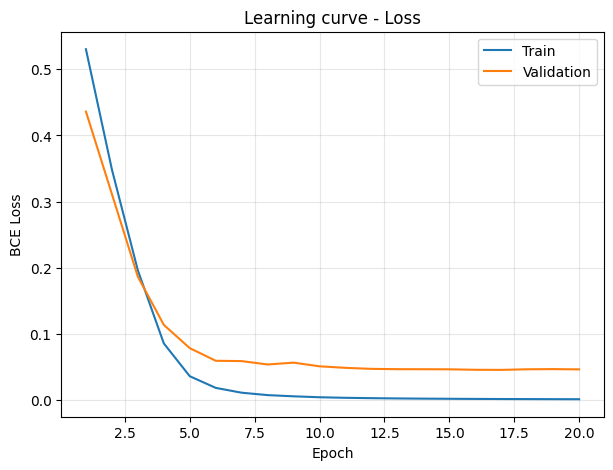

In [14]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 5))

plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Learning curve - Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

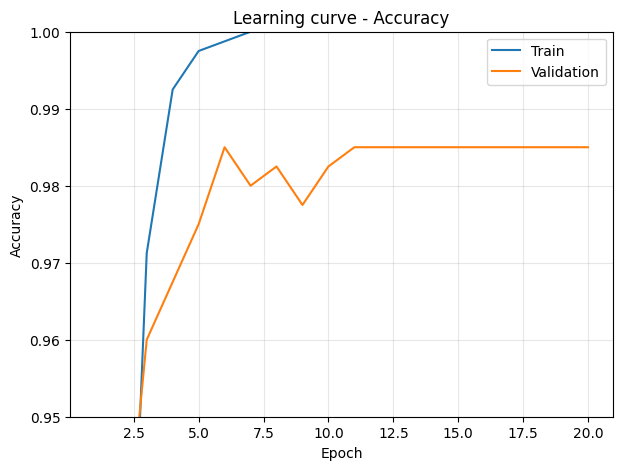

In [15]:
plt.figure(figsize=(7, 5))

plt.plot(epochs, train_accuracies, label="Train")
plt.plot(epochs, val_accuracies, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning curve - Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0.95, 1)
plt.show()

In [16]:
!ls

Datos_Ising.ipynb         NN_Sklearn.ipynb          temperatura_critica.npz
NN_Cero.ipynb             best_ising_mlp.pt         temperatura_critica20.npz
NN_Pytorch.ipynb          ising_dataset.npz


In [17]:
model.load_state_dict(
    torch.load("best_ising_mlp.pt", map_location=device)
)

model.eval()

IsingMLP(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [18]:
test_loss_total = 0.0
test_correct = 0
test_total = 0

all_probs = []
all_labels = []
all_temperatures = []

with torch.no_grad():

    for X_batch, y_batch, T_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward
        z = model(X_batch)

        # Loss
        loss = loss_fn(z, y_batch)

        # Probabilidades
        p = torch.sigmoid(z)

        # Clasificación 0/1
        predictions = (p >= 0.5).float()

        # Acumular loss
        test_loss_total += loss.item() * X_batch.size(0)

        # Accuracy
        test_correct += (predictions == y_batch).sum().item()

        test_total += y_batch.size(0)

        # Guardamos resultados para analizarlos después
        all_probs.append(p.cpu())
        all_labels.append(y_batch.cpu())
        all_temperatures.append(T_batch.cpu())


test_loss = test_loss_total / test_total
test_accuracy = test_correct / test_total

print(f"Test Loss:     {test_loss:.5f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss:     0.05793
Test Accuracy: 0.9750


In [19]:
all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)
all_temperatures = torch.cat(all_temperatures)

print(all_probs.shape)
print(all_labels.shape)
print(all_temperatures.shape)

torch.Size([400])
torch.Size([400])
torch.Size([400])


In [20]:
import numpy as np
import matplotlib.pyplot as plt

temps = all_temperatures.numpy()
probs = all_probs.numpy()

unique_T = np.unique(temps)

mean_p = []
std_p = []

for temp in unique_T:

    mask = temps == temp

    mean_p.append(probs[mask].mean())
    std_p.append(probs[mask].std())

mean_p = np.array(mean_p)
std_p = np.array(std_p)

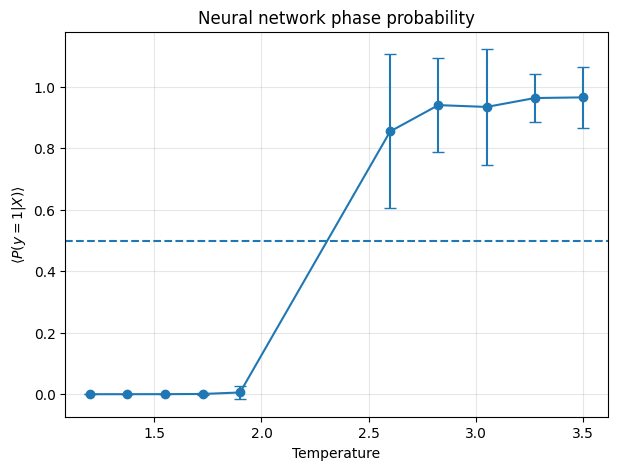

In [21]:
plt.figure(figsize=(7,5))

plt.errorbar(
    unique_T,
    mean_p,
    yerr=std_p,
    fmt="o-",
    capsize=4
)

plt.axhline(0.5, linestyle="--")

plt.xlabel("Temperature")
plt.ylabel(r"$\langle P(y=1|X)\rangle$")
plt.title("Neural network phase probability")

plt.grid(alpha=0.3)

plt.show()

In [22]:
datosTc = np.load('temperatura_critica.npz', allow_pickle=False)
datosTc

NpzFile 'temperatura_critica.npz' with keys: X, T, m, realizacion, y_ref...

In [23]:
X = datosTc["X"]
T = datosTc["T"]
m = datosTc["m"]
realizacion = datosTc["realizacion"]

In [24]:
print("X:", X.shape)
print("T:", T.shape)
print("m:", m.shape)
print("realizacion:", realizacion.shape)

print("\nTemperaturas:")
print(np.unique(T))

print("\nRealizaciones:")
print(np.unique(realizacion))

X: (6200, 16, 16)
T: (6200,)
m: (6200,)
realizacion: (6200,)

Temperaturas:
[1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]

Realizaciones:
[0 1 2 3]


In [25]:
X_tc = torch.tensor(
    X,
    dtype=torch.float32
).reshape(-1, 256)

T_tc = torch.tensor(
    T,
    dtype=torch.float32
)

realizacion_tc = torch.tensor(
    realizacion,
    dtype=torch.long
)

print(X_tc.shape)

torch.Size([6200, 256])


In [26]:
from torch.utils.data import TensorDataset, DataLoader

tc_dataset = TensorDataset(
    X_tc,
    T_tc,
    realizacion_tc
)

tc_loader = DataLoader(
    tc_dataset,
    batch_size=64,
    shuffle=False
)

In [27]:
model.eval()

IsingMLP(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [28]:
model.eval()

all_probs_tc = []
all_pred_tc = []
all_T_tc = []
all_r_tc = []

with torch.no_grad():

    for X_batch, T_batch, r_batch in tc_loader:

        X_batch = X_batch.to(device)

        # Salida de la red
        z = model(X_batch)

        # Probabilidad
        p = torch.sigmoid(z)

        # Clasificación 0/1
        pred = (p >= 0.5).long()

        all_probs_tc.append(p.cpu())
        all_pred_tc.append(pred.cpu())
        all_T_tc.append(T_batch)
        all_r_tc.append(r_batch)

In [29]:
all_probs_tc = torch.cat(all_probs_tc).numpy()
all_pred_tc = torch.cat(all_pred_tc).numpy()
all_T_tc = torch.cat(all_T_tc).numpy()
all_r_tc = torch.cat(all_r_tc).numpy()

In [30]:
print(all_probs_tc[:10])
print(all_pred_tc[:10])
print(all_T_tc[:10])
print(all_r_tc[:10])

[0.99049765 0.99702144 0.9998523  0.9992268  0.9995011  0.9851761
 0.997011   0.99937147 0.98307735 0.99583495]
[1 1 1 1 1 1 1 1 1 1]
[3.2 3.2 3.2 3.2 3.2 3.2 3.2 3.2 3.2 3.2]
[0 0 0 0 0 0 0 0 0 0]


In [31]:
import pandas as pd

df = pd.DataFrame({
    "T": all_T_tc,
    "realizacion": all_r_tc,
    "probabilidad": all_probs_tc,
    "prediccion": all_pred_tc
})

resumen = (
    df
    .groupby(["realizacion", "T"])
    .agg(
        prob_media=("probabilidad", "mean"),
        prob_std=("probabilidad", "std"),
        fraccion_y1=("prediccion", "mean"),
        N=("prediccion", "size")
    )
    .reset_index()
)

print(resumen)

     realizacion    T  prob_media  prob_std  fraccion_y1   N
0              0  1.6    0.000378  0.000304         0.00  50
1              0  1.7    0.000867  0.001414         0.00  50
2              0  1.8    0.001350  0.002558         0.00  50
3              0  1.9    0.001959  0.004291         0.00  50
4              0  2.0    0.008381  0.022180         0.00  50
..           ...  ...         ...       ...          ...  ..
119            3  2.8    0.954178  0.108397         1.00  50
120            3  2.9    0.929716  0.177788         0.94  50
121            3  3.0    0.931186  0.184051         0.94  50
122            3  3.1    0.975475  0.050271         1.00  50
123            3  3.2    0.968634  0.095610         0.98  50

[124 rows x 6 columns]


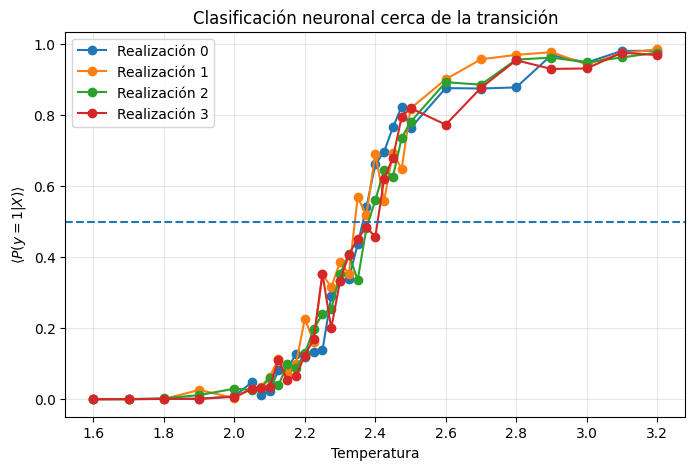

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for r in np.unique(all_r_tc):

    datos_r = resumen[
        resumen["realizacion"] == r
    ]

    plt.plot(
        datos_r["T"],
        datos_r["prob_media"],
        "o-",
        label=f"Realización {r}"
    )

plt.axhline(
    0.5,
    linestyle="--"
)

plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(y=1|X)\rangle$")
plt.title("Clasificación neuronal cerca de la transición")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
Tc_realizaciones = []

for r in np.unique(all_r_tc):

    datos_r = resumen[
        resumen["realizacion"] == r
    ].sort_values("T")

    temperaturas = datos_r["T"].to_numpy()
    probabilidades = datos_r["prob_media"].to_numpy()

    # buscar dónde cruza P = 0.5
    for i in range(len(temperaturas) - 1):

        p1 = probabilidades[i]
        p2 = probabilidades[i + 1]

        if p1 <= 0.5 <= p2:

            T1 = temperaturas[i]
            T2 = temperaturas[i + 1]

            # interpolación lineal
            Tc = T1 + (0.5 - p1) * (T2 - T1) / (p2 - p1)

            Tc_realizaciones.append(Tc)

            print(
                f"Realización {r}: "
                f"Tc = {Tc:.4f}"
            )

            break

Realización 0: Tc = 2.3651
Realización 1: Tc = 2.3421
Realización 2: Tc = 2.3805
Realización 3: Tc = 2.4066


In [34]:
Tc_realizaciones = np.array(Tc_realizaciones)

Tc_mean = Tc_realizaciones.mean()
Tc_std = Tc_realizaciones.std(ddof=1)

print()
print("Tc por realización:", Tc_realizaciones)
print(f"Tc promedio = {Tc_mean:.4f}")
print(f"Desviación estándar = {Tc_std:.4f}")


Tc por realización: [2.36510593 2.3420974  2.38051227 2.40662445]
Tc promedio = 2.3736
Desviación estándar = 0.0271


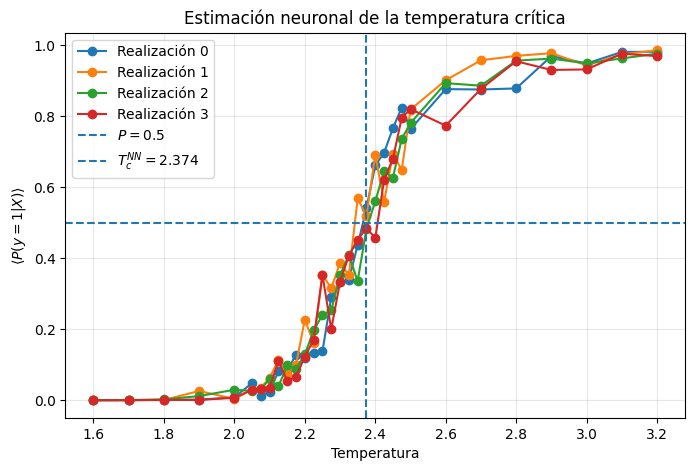

In [35]:
plt.figure(figsize=(8, 5))

for r in np.unique(all_r_tc):

    datos_r = resumen[
        resumen["realizacion"] == r
    ]

    plt.plot(
        datos_r["T"],
        datos_r["prob_media"],
        "o-",
        label=f"Realización {r}"
    )

plt.axhline(
    0.5,
    linestyle="--",
    label=r"$P=0.5$"
)

plt.axvline(
    Tc_mean,
    linestyle="--",
    label=fr"$T_c^{{NN}}={Tc_mean:.3f}$"
)

plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(y=1|X)\rangle$")
plt.title("Estimación neuronal de la temperatura crítica")

plt.legend()
plt.grid(alpha=0.3)

plt.show()